# Tutorial 8 - Design of Experiments: $2^3$ Factorial Screening

In this tutorial, you will run a DOE screening experiment using a paper airplane with 3 factors at 2 levels. The response variable is **time of flight** (seconds).

This tutorial walks through Phase 1 (Screening) of your DOE project. The contour and surface plots at the end preview a bit of Phase 2 (Optimization/RSM), which Tutorial 9 and your project will build on.

### Factors
Study how three factors affect **time of flight** (in seconds):

- **A: Wingspan** (`-1 = narrow`, `+1 = wide`)
- **B: Nose weight** (`-1 = no paperclip`, `+1 = one paperclip`)
- **C: Launch angle** (`-1 = shallow at ~25 degrees`, `+1 = steep at 45 degrees`)

### Response

Time of flight (seconds), measured from the moment of release to when the airplane touches the ground. Use any timing method (phone stopwatch, timer app, etc.) but be consistent across all runs.

For the demonstration, we will use "The Buzz" paper airplane design. For your own experiment, you can use any design from: https://www.foldnfly.com/#/1-1-1-1-1-1-1-1-2-1

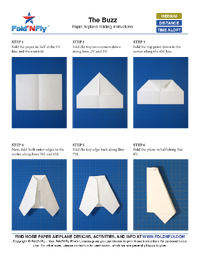  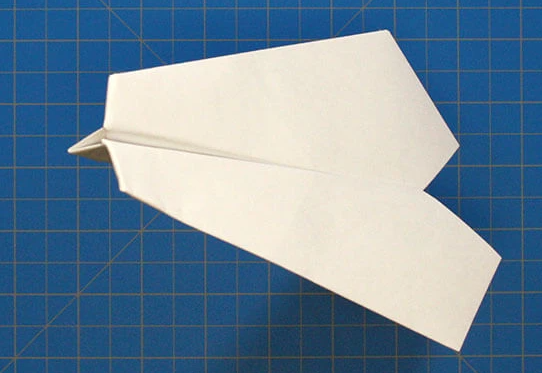

### **MINI-TASK: Show Me Your Airplane!**

Snap a photo of your paper airplane and include it below. You don't need to use a design from foldnfly.com, but let us know which design you used, even if it's your own design :) (name or link if applicable).

**ATTACH HERE:**

---

In [ ]:
%reset

## Step 1: Import Libraries and Set Up the Coded $2^3$ Factorial Design

We use:
- `pandas` for the data table
- `numpy` for calculations
- `statsmodels` for the factorial model
- `matplotlib` for plotting

In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

Create the coded $2^3$ factorial design. The standard treatment combinations are shown below in coded form.

In [3]:
# Standard 2^3 factorial design in coded units
design = pd.DataFrame({
    "Run": [1,2,3,4,5,6,7,8],
    "A":   [-1, 1,-1, 1,-1, 1,-1, 1],
    "B":   [-1,-1, 1, 1,-1,-1, 1, 1],
    "C":   [-1,-1,-1,-1, 1, 1, 1, 1]
})

design

,Run,A,B,C
0,1,-1,-1,-1
1,2,1,-1,-1
2,3,-1,1,-1
3,4,1,1,-1
4,5,-1,-1,1
5,6,1,-1,1
6,7,-1,1,1
7,8,1,1,1


Add the real-world meaning of each factor level.

In [4]:
label_map_A = {-1: "Narrow wingspan",  1: "Wide wingspan"}
label_map_B = {-1: "No paperclip",       1: "One paperclip"}
label_map_C = {-1: "Shallow throw",      1: "Steep throw"}

design_labeled = design.copy()
design_labeled["A_label"] = design_labeled["A"].map(label_map_A)
design_labeled["B_label"] = design_labeled["B"].map(label_map_B)
design_labeled["C_label"] = design_labeled["C"].map(label_map_C)

design_labeled

,Run,A,B,C,A_label,B_label,C_label
0,1,-1,-1,-1,Narrow wingspan,No paperclip,Shallow throw
1,2,1,-1,-1,Wide wingspan,No paperclip,Shallow throw
2,3,-1,1,-1,Narrow wingspan,One paperclip,Shallow throw
3,4,1,1,-1,Wide wingspan,One paperclip,Shallow throw
4,5,-1,-1,1,Narrow wingspan,No paperclip,Steep throw
5,6,1,-1,1,Wide wingspan,No paperclip,Steep throw
6,7,-1,1,1,Narrow wingspan,One paperclip,Steep throw
7,8,1,1,1,Wide wingspan,One paperclip,Steep throw


## Procedure

Construct the paper airplane according to the factor levels for each run.

For each run:
- Configure the airplane according to A, B, and C.
- Throw the airplane.
- Start timing at the moment of release and stop when the airplane touches the ground.
- Record the time of flight in seconds in the data table.

### **QUESTION 1**

(a) Why is performing the experiment indoors rather than outdoors an example of experimental control of nuisance factors?

(b) What other nuisance factors could you control for?

(c) Why do you randomize the order of the experimental runs?

(d) Suppose the thrower becomes better at throwing airplanes over time. If you did not randomize the order, what could happen?

**ANSWER:**

## Step 2: Randomize the Experimental Run Order


In [5]:
import pandas as pd

design = pd.DataFrame({
    "Run": [1,2,3,4,5,6,7,8],
    "A":   [-1, 1,-1, 1,-1, 1,-1, 1],
    "B":   [-1,-1, 1, 1,-1,-1, 1, 1],
    "C":   [-1,-1,-1,-1, 1, 1, 1, 1]
})

randomized = design.sample(frac=1, random_state=42).reset_index(drop=True)
randomized["RandomOrder"] = range(1, 9)
randomized = randomized[["RandomOrder", "Run", "A", "B", "C"]]

print(randomized)

   RandomOrder  Run  A  B  C
0            1    2  1 -1 -1
1            2    6  1 -1  1
2            3    1 -1 -1 -1
3            4    8  1  1  1
4            5    3 -1  1 -1
5            6    5 -1 -1  1
6            7    4  1  1 -1
7            8    7 -1  1  1


## Step 3: Experimental Runs for a Single $2^3$ Full Factorial

Throw the airplane 8 times under the designed conditions (in randomized order) and record the time of flight for each run.

### **TASK 1: Enter Your Experimental Data**

Replace the placeholder values below with your own time of flight measurements (in seconds) from the 8 experimental runs.

In [6]:
# -------------------------------------------------------------------
# ENTER YOUR TIME OF FLIGHT MEASUREMENTS HERE
# Replace the placeholder values below with your recorded data.
# Each value corresponds to the run order in the design matrix above.
# -------------------------------------------------------------------

time_of_flight = [1.8, 2.4, 1.5, 2.1, 2.9, 3.5, 2.3, 2.8] # Replace with your data

dfa = design.copy()
dfa["TimeOfFlight"] = time_of_flight

dfa

,Run,A,B,C,TimeOfFlight
0,1,-1,-1,-1,1.8
1,2,1,-1,-1,2.4
2,3,-1,1,-1,1.5
3,4,1,1,-1,2.1
4,5,-1,-1,1,2.9
5,6,1,-1,1,3.5
6,7,-1,1,1,2.3
7,8,1,1,1,2.8


## Step 4: Fit the Full $2^3$ Factorial Model

The coded regression model is:

$$y = \beta_0 + \beta_A A + \beta_B B + \beta_C C + \beta_{AB} AB + \beta_{AC} AC + \beta_{BC} BC + \beta_{ABC} ABC + \varepsilon$$

In a $2^3$ design with one observation per treatment combination, this is a **saturated model**. That means the fitted values match the observed values exactly, and classical p-values are not available without replication. Even so, the effect estimates are still useful for screening and interpretation.

In [7]:
model = ols("TimeOfFlight ~ A + B + C + A:B + A:C + B:C + A:B:C", data=dfa)
results=model.fit()
print(results.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     nan      
Dependent Variable: TimeOfFlight     AIC:                -518.0333
Date:               2026-04-14 12:50 BIC:                -517.3977
No. Observations:   8                Log-Likelihood:     267.02   
Df Model:           7                F-statistic:        nan      
Df Residuals:       0                Prob (F-statistic): nan      
R-squared:          1.000            Scale:              inf      
--------------------------------------------------------------------
               Coef.    Std.Err.      t      P>|t|   [0.025   0.975]
--------------------------------------------------------------------
Intercept      2.4125        inf    0.0000     nan      nan      nan
A              0.2875        inf    0.0000     nan      nan      nan
B             -0.2375        inf   -0.0000     nan      nan      nan
C              0.4625        inf    0.0000     nan      nan      nan

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)


In [8]:
from statsmodels.stats.anova import anova_lm

anova_lm(results)

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\anova.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  (model.ssr / model.df_resid))


,df,sum_sq,mean_sq,F,PR(>F)
A,1.0,6.612500e-01,0.66125,0.0,NaN
B,1.0,4.512500e-01,0.45125,0.0,NaN
C,1.0,1.711250e+00,1.71125,0.0,NaN
A:B,1.0,1.250000e-03,0.00125,0.0,NaN
A:C,1.0,1.250000e-03,0.00125,0.0,NaN
B:C,1.0,6.125000e-02,0.06125,0.0,NaN
A:B:C,1.0,1.250000e-03,0.00125,0.0,NaN
Residual,0.0,4.782469e-30,inf,NaN,NaN


### Cube Plot

Each corner of the cube represents one of the 8 experimental runs. The three axes are A, B, and C. The value at each corner is the observed time of flight for that combination of factor levels.

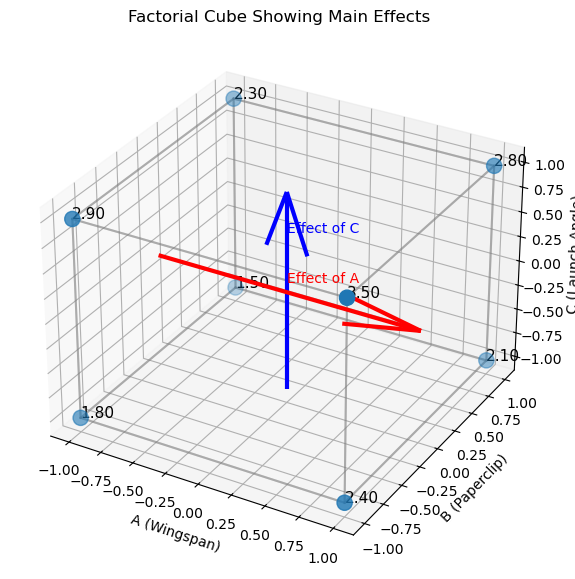

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Mean response at cube corners
cube_df = dfa.groupby(["A","B","C"], as_index=False)["TimeOfFlight"].mean()

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

# Plot cube corners
ax.scatter(cube_df["A"], cube_df["B"], cube_df["C"], s=120)

# Label responses
for _, row in cube_df.iterrows():
    ax.text(row["A"], row["B"], row["C"],
            f'{row["TimeOfFlight"]:.2f}',
            fontsize=11)

# Cube corners
corners = [
(-1,-1,-1),(1,-1,-1),(-1,1,-1),(1,1,-1),
(-1,-1,1),(1,-1,1),(-1,1,1),(1,1,1)
]

# Draw cube edges
for c1 in corners:
    for c2 in corners:
        diff = sum(abs(a-b) for a,b in zip(c1,c2))
        if diff == 2:
            ax.plot([c1[0],c2[0]],
                    [c1[1],c2[1]],
                    [c1[2],c2[2]],
                    color="gray", alpha=0.4)

# Arrow showing main effect of A
ax.quiver(-1,0,0, 2,0,0, color="red", linewidth=3)
ax.text(0,0,0.1,"Effect of A", color="red")

# Arrow showing main effect of C
ax.quiver(0,0,-1, 0,0,2, color="blue", linewidth=3)
ax.text(0,0,0.6,"Effect of C", color="blue")

ax.set_xlabel("A (Wingspan)")
ax.set_ylabel("B (Paperclip)")
ax.set_zlabel("C (Launch Angle)")

ax.set_title("Factorial Cube Showing Main Effects")

plt.show()

## Step 5: Pareto Plot of Absolute Effects

A Pareto plot ranks effects from largest to smallest. This is especially useful in a screening experiment because it visually identifies which factors and interactions have the strongest influence on the response.

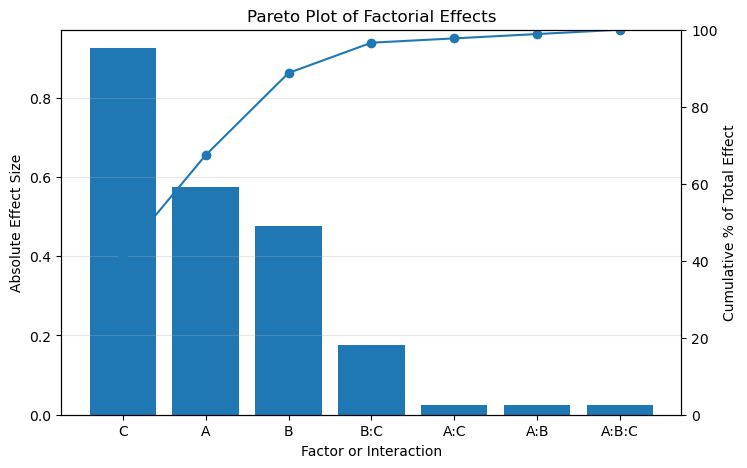

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coef = results.params.drop("Intercept")

# Convert regression coefficients to factorial effects
effects = 2 * coef

pareto_df = pd.DataFrame({
    "Term": effects.index,
    "Effect": effects.values
})

pareto_df["AbsEffect"] = pareto_df["Effect"].abs()

# Sort largest → smallest for Pareto
pareto_df = pareto_df.sort_values("AbsEffect", ascending=False)

# Compute cumulative percentage
pareto_df["CumPercent"] = pareto_df["AbsEffect"].cumsum() / pareto_df["AbsEffect"].sum() * 100

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar plot
ax1.bar(pareto_df["Term"], pareto_df["AbsEffect"])
ax1.set_ylabel("Absolute Effect Size")
ax1.set_xlabel("Factor or Interaction")
ax1.set_title("Pareto Plot of Factorial Effects")
ax1.grid(axis="y", alpha=0.3)

# Second axis for cumulative line
ax2 = ax1.twinx()
ax2.plot(pareto_df["Term"], pareto_df["CumPercent"], marker="o")
ax2.set_ylabel("Cumulative % of Total Effect")
ax2.set_ylim(0,100)

plt.show()

## Step 6: Interaction Plots

If lines are close to parallel, the interaction is weak. If lines are clearly non-parallel or cross, the interaction may be important.

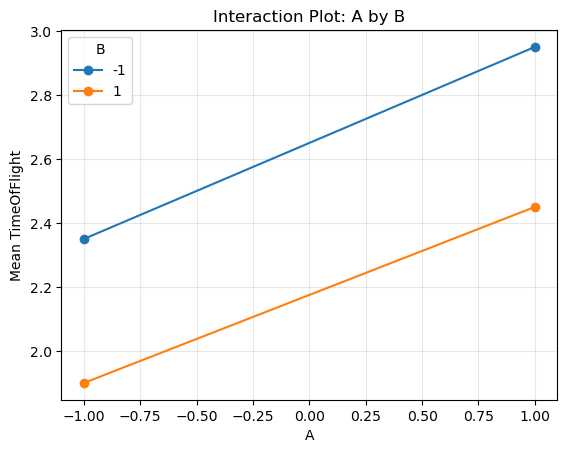

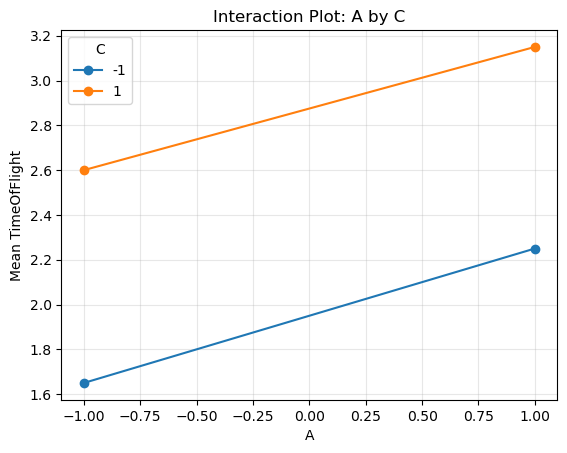

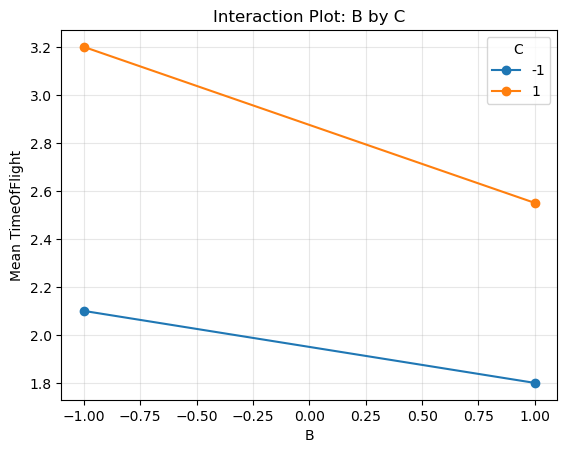

In [11]:
def interaction_plot(df, x, trace, response="TimeOfFlight"):
    means = df.groupby([x, trace])[response].mean().unstack()
    means.plot(marker="o")
    plt.xlabel(x)
    plt.ylabel(f"Mean {response}")
    plt.title(f"Interaction Plot: {x} by {trace}")
    plt.grid(alpha=0.3)
    plt.show()

interaction_plot(dfa, "A", "B")
interaction_plot(dfa, "A", "C")
interaction_plot(dfa, "B", "C")

### **QUESTION 2**

Based on the Pareto plot and interaction plots above:

(a) Which main effect is largest in magnitude?

(b) Does increasing that factor improve or reduce time of flight?

(c) Why is there no MSE or inferential statistical information?

(d) Which interaction is largest?

(e) Does the Pareto plot suggest a small number of active effects?

(f) If you had to choose two factors for a follow-up optimization study, which would you keep? Justify your choice.

**ANSWER:**

## Step 7: Reduce to 2 Factors and Re-fit the Model

Based on your screening results, keep the two most important factors, hold the third fixed, and fit a reduced $2^2$ model.

**Note:** The code below uses A and C as the two chosen factors. If your Pareto plot suggests a different pair is more important, update the formula accordingly (e.g., `A * B` or `B * C`).

**DOE Project connection:** This is the "factor reduction" step. Your project requires you to defend which two quantitative factors you carry forward into the optimization phase.

In [12]:
# Reduced model - update the formula if your two most important factors differ
reduced_model = ols("TimeOfFlight ~ A * C", data=dfa)
reduced_results=reduced_model.fit()
print(reduced_results.summary())

                            OLS Regression Results                            
Dep. Variable:           TimeOfFlight   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     6.146
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0559
Time:                        12:50:49   Log-Likelihood:               -0.37939
No. Observations:                   8   AIC:                             8.759
Df Residuals:                       4   BIC:                             9.077
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4125      0.127     19.017      0.0

## Step 8: Relate Regression Coefficients to Factorial Effects

For coded $(-1, +1)$ variables:

$$\text{Effect} = 2 \times \text{Coefficient}$$

### **TASK 2: Hand-Drawn Factorial Plots**

Using the corner values from the reduced model above:

(a) Draw the factorial box plot (square with your two chosen factors on the axes and mean response values at each corner). Label the main effects on the plot.

(b) Sketch a contour plot by hand, showing approximate contour lines through the design space.

Include a photo or scan of your hand-drawn plots in the cell below.

**ANSWER:**

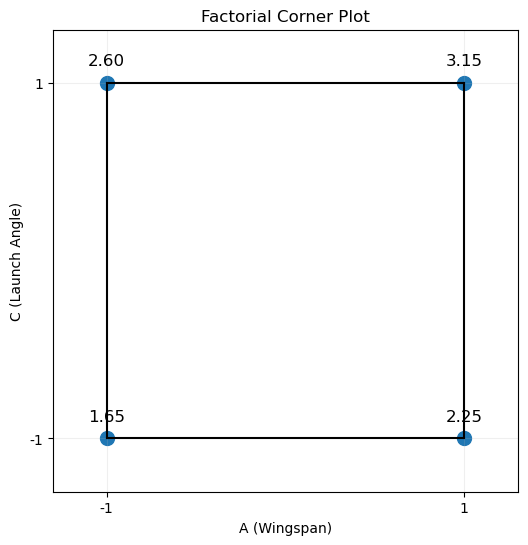

In [13]:
import matplotlib.pyplot as plt

# Compute means
pivot = dfa.pivot_table(values="TimeOfFlight", index="C", columns="A", aggfunc="mean")

plt.figure(figsize=(6,6))

# Draw square boundary
plt.plot([-1, 1], [-1, -1], 'k-')
plt.plot([-1, 1], [ 1,  1], 'k-')
plt.plot([-1, -1], [-1, 1], 'k-')
plt.plot([ 1,  1], [-1, 1], 'k-')

# Draw corner points
plt.scatter([-1, 1, -1, 1], [-1, -1, 1, 1], s=100)

# Put the mean responses at the corners
corner_values = {
    (-1, -1): pivot.loc[-1, -1],
    ( 1, -1): pivot.loc[-1,  1],
    (-1,  1): pivot.loc[ 1, -1],
    ( 1,  1): pivot.loc[ 1,  1]
}

for (a, c), val in corner_values.items():
    plt.text(a, c + 0.08, f"{val:.2f}", ha="center", va="bottom", fontsize=12)

# Axis labels and formatting
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)
plt.xticks([-1, 1], [-1, 1])
plt.yticks([-1, 1], [-1, 1])

plt.xlabel("A (Wingspan)")
plt.ylabel("C (Launch Angle)")
plt.title("Factorial Corner Plot")

plt.grid(alpha=0.2)
plt.show()

## Step 9: Surface Plot and Contour Plot

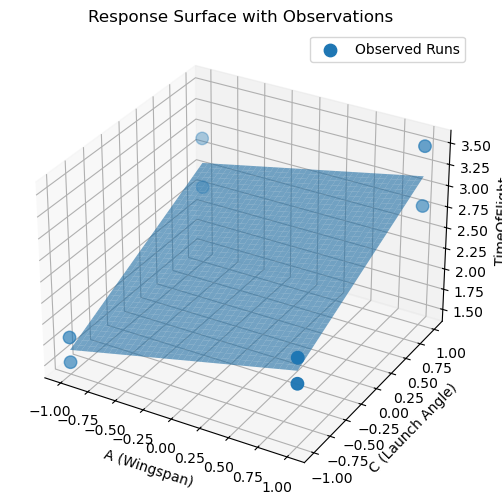

In [14]:
# Response Surface
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create grid
A_vals = np.linspace(-1, 1, 40)
C_vals = np.linspace(-1, 1, 40)
A_grid, C_grid = np.meshgrid(A_vals, C_vals)

# Put grid into dataframe for prediction
grid_df = pd.DataFrame({
    "A": A_grid.ravel(),
    "C": C_grid.ravel()
})

# Predict from fitted model
grid_df["Predicted_TimeOfFlight"] = reduced_results.predict(grid_df)

# Reshape predictions back to grid
Z = grid_df["Predicted_TimeOfFlight"].values.reshape(A_grid.shape)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

# Surface
ax.plot_surface(A_grid, C_grid, Z, alpha=0.6)

# Observed data points
ax.scatter(
    dfa["A"],
    dfa["C"],
    dfa["TimeOfFlight"],
    s=80,
    marker="o",
    label="Observed Runs"
)

ax.set_xlabel("A (Wingspan)")
ax.set_ylabel("C (Launch Angle)")
ax.set_zlabel("TimeOfFlight")
ax.set_title("Response Surface with Observations")

ax.legend()

plt.show()

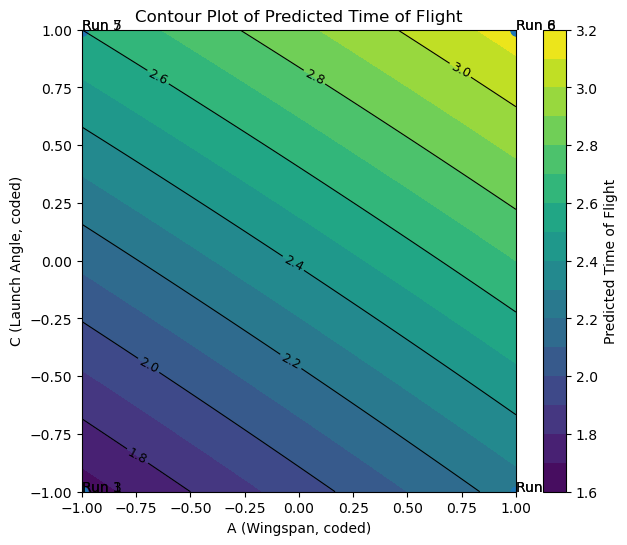

In [15]:
# Contour Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Filled contours
cp = plt.contourf(A_vals, C_vals, Z, levels=15)

# Contour lines
cs = plt.contour(A_vals, C_vals, Z, colors="black", linewidths=0.8)
plt.clabel(cs, inline=True, fontsize=9)

# Observed design points
plt.scatter(design["A"], design["C"], s=60)

# Label run numbers
for _, row in design.iterrows():
    plt.text(row["A"], row["C"], f'Run {row["Run"]}', fontsize=10)

plt.xlabel("A (Wingspan, coded)")
plt.ylabel("C (Launch Angle, coded)")
plt.title("Contour Plot of Predicted Time of Flight")

plt.colorbar(cp, label="Predicted Time of Flight")

plt.show()

### **QUESTION 3**

Based on the surface plot and contour plot above:

(a) What do the contour lines in a contour plot represent?

(b) From the contour plot or response surface, where would you expect the maximum time of flight to occur?

(c) How does the shape of the response surface indicate whether an interaction is present between your two chosen factors?

(d) In which direction should the experimenter move to increase time of flight, outside of this design region?

**ANSWER:**

---

# Submission Instructions

**Due Date:** Friday, March 20, 2026

**How to Submit:**
1. Make sure all code cells have been run and show outputs
2. Make sure all TASK cells are completed with your code or hand-drawn plots
3. Make sure all QUESTION cells are filled in with your answers
4. Save your notebook as: `Tutorial8_YourName.ipynb` (replace "YourName" with your actual name)
5. Export as PDF (File -> Save and Export Notebook As -> PDF)
6. Submit both the .ipynb and PDF to the Tutorial 8 dropbox on Avenue to Learn

**Need Help?**
- Jala and Imran will be available during office hours **Wednesday** and **Thursday**
- Check Avenue to Learn for office hours times and locations
- You can also post questions on the course discussion board